In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("../data/Mall_Customers.csv")

# Rename columns
df.columns = [
    "customer_id",
    "gender",
    "age",
    "annual_income",
    "spending_score"
]

# Display first rows
df.head()

,customer_id,gender,age,annual_income,spending_score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [2]:
# Dataset shape
print("Dataset Shape:", df.shape)

# Dataset information
df.info()

# Statistical summary
df.describe()

Dataset Shape: (200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     200 non-null    int64 
 1   gender          200 non-null    object
 2   age             200 non-null    int64 
 3   annual_income   200 non-null    int64 
 4   spending_score  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,customer_id,age,annual_income,spending_score
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [3]:
# Check missing values
df.isnull().sum()

customer_id       0
gender            0
age               0
annual_income     0
spending_score    0
dtype: int64

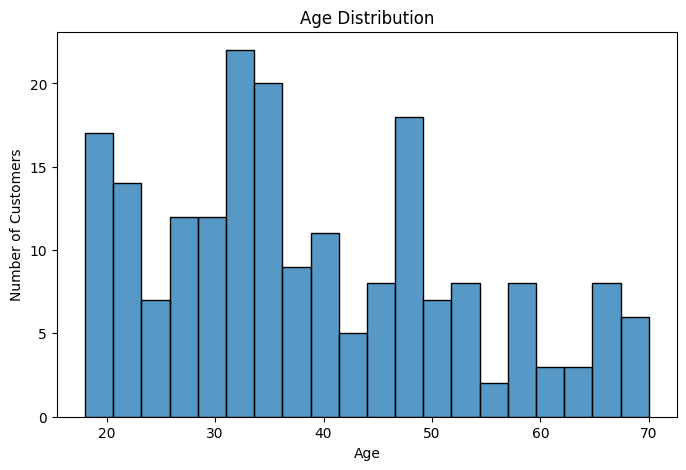

In [4]:
plt.figure(figsize=(8,5))

sns.histplot(df["age"], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

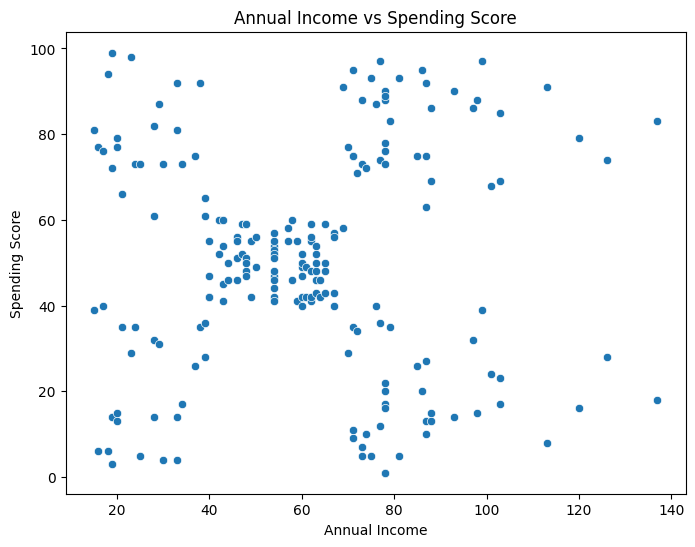

In [5]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["annual_income"],
    y=df["spending_score"]
)

plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")

plt.show()

In [6]:
from sklearn.cluster import KMeans

# Selecting features
X = df[["annual_income", "spending_score"]]

# WCSS list
wcss = []

# Finding optimal number of clusters
for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init="k-means++",
        random_state=42
    )

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

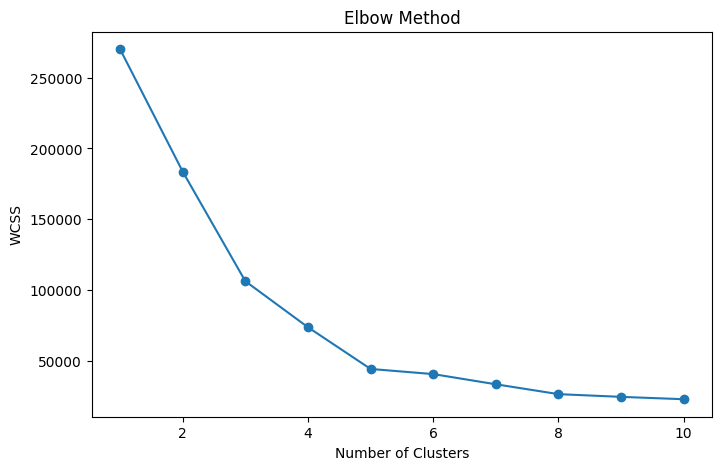

In [7]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [8]:
# Applying K-Means

kmeans = KMeans(
    n_clusters=5,
    init="k-means++",
    random_state=42
)

# Predict clusters
y_kmeans = kmeans.fit_predict(X)

# Add cluster labels to dataframe
df["cluster"] = y_kmeans

# Display first rows
df.head()

,customer_id,gender,age,annual_income,spending_score,cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


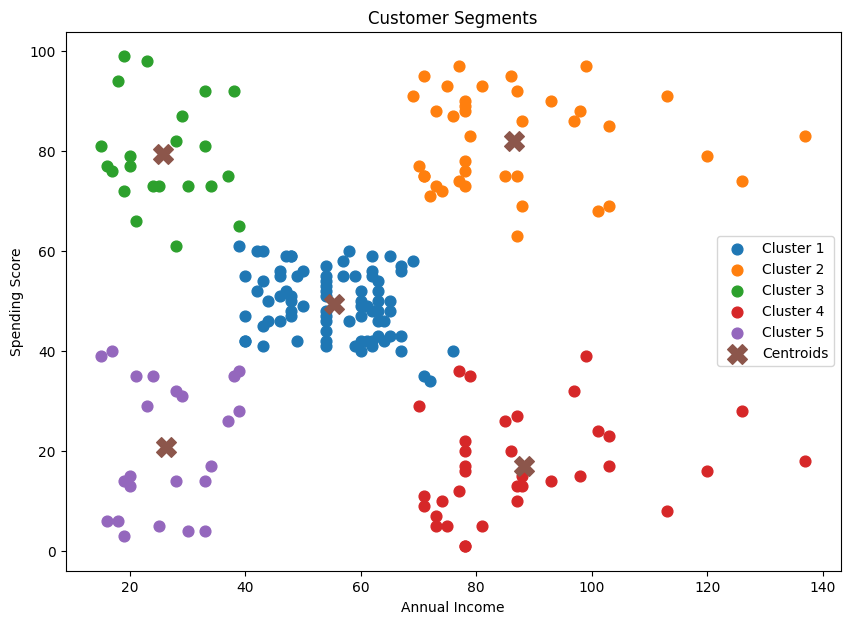

In [9]:
plt.figure(figsize=(10,7))

plt.scatter(
    X.iloc[y_kmeans == 0, 0],
    X.iloc[y_kmeans == 0, 1],
    s=60,
    label='Cluster 1'
)

plt.scatter(
    X.iloc[y_kmeans == 1, 0],
    X.iloc[y_kmeans == 1, 1],
    s=60,
    label='Cluster 2'
)

plt.scatter(
    X.iloc[y_kmeans == 2, 0],
    X.iloc[y_kmeans == 2, 1],
    s=60,
    label='Cluster 3'
)

plt.scatter(
    X.iloc[y_kmeans == 3, 0],
    X.iloc[y_kmeans == 3, 1],
    s=60,
    label='Cluster 4'
)

plt.scatter(
    X.iloc[y_kmeans == 4, 0],
    X.iloc[y_kmeans == 4, 1],
    s=60,
    label='Cluster 5'
)

# Plot centroids
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=200,
    marker='X',
    label='Centroids'
)

plt.title("Customer Segments")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")

plt.legend()

plt.show()